# RQ1: How does average viewership and engagement of conservative and liberal YouTube channels change over time?

In [1]:
from pymongo import MongoClient
import pandas as pd

# Connect
client = MongoClient("mongodb://localhost:27017/")
db = client["group4"]
collection = db["youtube"]

pipeline = [
    # Flatten videos array
    {"$unwind": "$videos"},

    # Group data
    {
        "$group": {
            "_id": {
                "lean": "$videos.lean",
                "year": "$videos.year"
            },
            "avg_views": {"$avg": "$videos.view_count"},
            "avg_likes": {"$avg": "$videos.like_count"},
            "avg_comments": {"$avg": "$videos.comment_count"}
        }
    },

    {
        "$project": {
            "_id": 0,
            "lean": "$_id.lean",
            "year": "$_id.year",

            "avg_views": {"$round": ["$avg_views", 2]},
            "avg_likes": {"$round": ["$avg_likes", 2]},
            "avg_comments": {"$round": ["$avg_comments", 2]},

            "like_rate_percent": {
                "$round": [
                    {
                        "$multiply": [
                            {"$divide": ["$avg_likes", "$avg_views"]},
                            100
                        ]
                    },
                    2
                ]
            },

            "comment_rate_percent": {
                "$round": [
                    {
                        "$multiply": [
                            {"$divide": ["$avg_comments", "$avg_views"]},
                            100
                        ]
                    },
                    2
                ]
            }
        }
    },

    # Sort by year, lean
    {"$sort": {"year": 1, "lean": 1}}
]

# Execute
results = list(db.youtube.aggregate(pipeline))
rq1_df = pd.DataFrame(results)

display(rq1_df.head())

,lean,year,avg_views,avg_likes,avg_comments,like_rate_percent,comment_rate_percent
0,conservative,2018,98931.87,2807.23,472.17,2.84,0.48
1,liberal,2018,664.98,3.58,1.30,0.54,0.20
2,conservative,2019,147282.83,4106.68,806.75,2.79,0.55
3,liberal,2019,67.55,0.58,0.30,0.86,0.44
4,conservative,2020,2089483.87,77850.17,10907.93,3.73,0.52


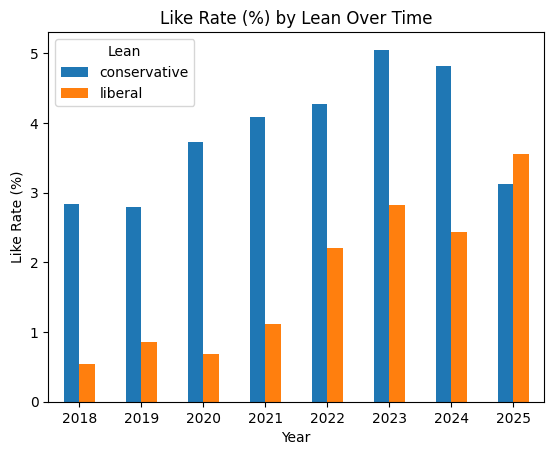

In [2]:
import matplotlib.pyplot as plt

pivot_df = rq1_df.pivot(index="year", columns="lean", values="like_rate_percent")

pivot_df.plot(kind="bar")

plt.title("Like Rate (%) by Lean Over Time")
plt.xlabel("Year")
plt.ylabel("Like Rate (%)")
plt.xticks(rotation=0)
plt.legend(title="Lean")

plt.show()